In [1]:
import os 
from dotenv import load_dotenv

import json 
import urllib.request
import urllib.parse

from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage,HumanMessage,ToolMessage
from langchain_community.utilities import WikipediaAPIWrapper,arxiv,ArxivAPIWrapper
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


from langgraph.graph.message import MessagesState
from langgraph.graph import StateGraph,END,START
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.types import Command,interrupt
from langgraph.checkpoint.memory import MemorySaver

import wikipedia




C:\Users\Malik\AppData\Local\Temp\ipykernel_19472\2796217759.py:11: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import WikipediaAPIWrapper,arxiv,ArxivAPIWrapper


In [2]:
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGSMITH_PROJECT")

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b")

In [3]:

wiki_api_wrapper = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=2000)
wiki_call = WikipediaQueryRun(api_wrapper=wiki_api_wrapper)


arxiv_api_wrapper = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=2000)
arxiv_call = ArxivQueryRun(api_wrapper=arxiv_api_wrapper)


@tool 
def getweather_api(city: str)->str:
    """Fetch real-time weather data for a specific city name."""
    encoded_city = urllib.parse.quote(city)
    geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={encoded_city}&count=1&language=en&format=json"
    try:
        with urllib.request.urlopen(geo_url) as geo_response:
            geo_data = json.loads(geo_response.read().decode())
            if not geo_data.get("results"):
                return f"Could not find coordinates for city: {city}"
            location = geo_data["results"][0]
            lat, lon = location["latitude"], location["longitude"]
            resolved_city = location["name"]

        weather_url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current_weather=true"
        with urllib.request.urlopen(weather_url) as weather_response:
            weather_data = json.loads(weather_response.read().decode())
            current = weather_data["current_weather"]
            return f"The current temperature in {resolved_city} is {current['temperature']}°C with wind speed {current['windspeed']} km/h."
    except Exception as e:
        return f"Error fetching weather data: {str(e)}"



# Combine into your final tool list
tools = [wiki_call, getweather_api, arxiv_call]

In [4]:
# This forces the LLM to only call ONE tool at a time, creating a strict ReAct loop.
t_llm = llm.bind_tools(tools, parallel_tool_calls=False)

from langgraph.prebuilt import ToolNode

# 1. Define the routing logic
def route_after_bot(state: MessagesState):
    """Route to approval if tools are called, otherwise end."""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0:
        return "approve_from_human"
    return END

# 2. Define the human approval node
def approve_from_human(state: MessagesState):
    """Pause execution and request human input."""
    last_message = state["messages"][-1]
    
    # The interrupt() function pauses the graph and surfaces this payload
    human_response = interrupt(
        f"The LLM wants to call tools: {[tc['name'] for tc in last_message.tool_calls]}. Type 'yes' to approve or 'no' to reject."
    )
    
    # Handle the human's resumed response
    if human_response.lower().strip() in ["yes", "y"]:
        # If approved, proceed directly to the tools node
        return Command(goto="tools")
    else:
        # If rejected, feed a cancellation message back to the LLM
        cancellation_messages = [
            ToolMessage(
                tool_call_id=tc["id"], 
                name=tc["name"], 
                content=f"Human explicitly rejected the request to call {tc['name']}."
            ) for tc in last_message.tool_calls
        ]
        return Command(
            update={"messages": cancellation_messages}, 
            goto="bot"
        )

# 3. Build and compile the graph
builder = StateGraph(MessagesState)

builder.add_node("bot", bot_node)
builder.add_node("approve_from_human", approve_from_human)
builder.add_node("tools", ToolNode(tools)) # Built-in node to execute your tools list

builder.add_edge(START, "bot")
# Use the custom router instead of the default tools_condition
builder.add_conditional_edges("bot", route_after_bot) 
builder.add_edge("tools", "bot")

# MemorySaver is required for interrupt() to checkpoint the state
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)                                       

NameError: name 'bot_node' is not defined

In [4]:
t_llm = llm.bind_tools(tools, parallel_tool_calls=False)
def bot_node(state:MessagesState):
    response=t_llm.invoke(state["messages"])
    return {"messages":[response]}
       



def rout_of_call(state:MessagesState):      
    """if the the LLM message have the specific tool call then call it if not so no reject it """
    lastmessage=state["messages"][-1]
    if  hasattr(lastmessage,"tool_call") and len(lastmessage.tool_calls)>0:
        return "aprove_from_human"
    return END



def approve_from_human(state:MessagesState):
    """Pause execution and request human input."""

    lastmessage=state["messages"][-1]
    response=interrupt( 
                     f"the LLM want to call the tool {[tc["name"] for tc in lastmessage.tool_calls]}.Type 'yes' approve  or 'no'  reject"  )

    if response.lower().strip() in ["yes",'y']:
        return  Command(
        goto='tools'
          ) 
    

    else:

        messagecancelation=[
            ToolMessage(

                 tool_call_id=tc["id"], 
                name=tc["name"], 
                content=f"Human explicitly rejected the request to call {tc['name']}."
                        ) for tc in response.tool_calls  ]


        return Command(
        update=messagecancelation,
        goto='bot'

        )
        



In [5]:
graph=StateGraph(MessagesState)

In [7]:
graph.add_node("bot", bot_node)
graph.add_node("approve_from_human", approve_from_human)
graph.add_node("tools", ToolNode(tools))

In [ ]:
graph.add_edge(START,"bot")
graph.add_conditional_edges("bot",rout_of_call)
graph.add_edge("tools","bot")
graph.add_edge("bot",END)





In [10]:
memory=MemorySaver()

In [17]:
app=graph.compile(checkpointer=memory)

In [16]:
from IPython.display import display,Image






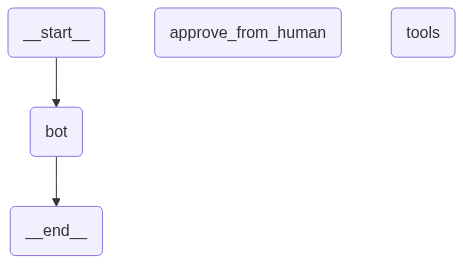

In [14]:
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
# A thread_id is mandatory so the graph knows which state to resume
config = {"configurable": {"thread_id": "thread_1"}}

# Step 1: Initial user prompt
initial_input = {"messages": [HumanMessage(content="What is the weather in Peshawar?")]}

print("--- INITIAL RUN ---")
for event in graph.stream(initial_input, config):
    print(event)

# The graph is now paused. You can inspect the state to confirm:
state = graph.get_state(config)
print("\nNext node to run:", state.next) # Will print ('approve_from_human',)

# Step 2: Resume with human approval
# We pass the human's response directly into Command(resume=...)
print("\n--- RESUMING RUN ---")
for event in graph.stream(Command(resume="yes"), config):
    print(event)